# Data Preparation *Chen2022*

Continuing with our *Chen2022* FEDS project set up.

We are assembling four geospatial datasets that FEDS will use to detect, track, and analyze California wildfires from satellite data. By loading all of the map layers before studying a fire. In the following four sections, we will direct the data to know where California is, what the land looks like, how dry it is, and where fires were detected.
  
The majority of the commands in these sections should be **run from a terminal** to prepare for the project.

## California Boundary Shapefile Setup

Here, we will downloads all 50 US state boundaries from the Census Bureau, then uses gdal's ogr2ogr to SQL-filter out only California and save it as California.shp in EPSG:4326 (standard GPS lat/lon)

From our scratch folder we will make the following folders.    
```cd scratch```   
  
We make the IMP_fire_2026 folder  
```mkdir IMP_fire_2026```  
  
We navigate to it   
```cd IMP_fire_2026```  
  
We make a new folder for extra data  
```mkdir ExtData```  
  
We navigate to it  
```cd ExtData```  
  
We make the California shape folder  
```mkdir Calshape```  
  
Check our file path to see all went well  
```pwd```  

Now let's get our data with wget:

In [ ]:
# Download Census 1:500k resolution state boundary projection shape file and unzip it
wget https://www2.census.gov/geo/tiger/GENZ2021/shp/cb_2021_us_state_500k.zip

unzip cb_2021_us_state_500k.zip

Next we run a spatial filtering and conversion command

```module load gdal```  load the gdal engine  
  
```ogr2ogr```   ogr2ogr converts and manipulates spatial data     
```-overwrite```  delete this file if it already exists  
```-f "ESRI Shapefile" California.shp```  format as a shapefile and name it CA  
```cb_2021_us_state_500k.shp```  the input file  
```-nln California```   New Layer Name     
```-where "NAME='California'"```  SQL, look in the name column and the CA row and keep it   

In [ ]:
module load gdal

ogr2ogr -overwrite -f "ESRI Shapefile" California.shp
cb_2021_us_state_500k.shp
-nln California
-where "NAME='California'"

Check our projection.  
In the following output we want to see that we have the correct data.  
  
Expected CRS: **EPSG:4326** (WGS84)

In [ ]:
ogrinfo -so California.shp California

If not EPSG:4326 we need to adjust by changing the map's math, how the Earth’s curves are flattened into coordinates:  
  
```ogr2ogr```   using this gdal tool  
```-t_srs```  Target Spatial Reference System change coordinates to   
```EPSG:4326```  in WGS 84 format used by GPS and google maps, lat/long   
```California.shp cb_2021_us_state_500k.shp```  the output and input files   

In [ ]:
ogr2ogr -t_srs EPSG:4326 California.shp cb_2021_us_state_500k.shp

# and check 

ogrinfo -so California.shp California

In [22]:
%cd /glade/derecho/scratch/jhana/IMP_fire_2026/ExtData/Calshape
!ls

/glade/derecho/scratch/jhana/IMP_fire_2026/ExtData/Calshape
California.dbf		   cb_2021_us_state_500k.shp
California.prj		   cb_2021_us_state_500k.shp.ea.iso.xml
California.shp		   cb_2021_us_state_500k.shp.iso.xml
California.shx		   cb_2021_us_state_500k.shx
cb_2021_us_state_500k.cpg  cb_2021_us_state_500k.zip
cb_2021_us_state_500k.dbf  cb_2021_us_state_500k.zip.1
cb_2021_us_state_500k.prj


## Plotting California  
Here, we are showing the shape file we just created in this section. The California boundary polygon with county-style styling, a compass rose, scale bar, and labeled key geographic points creat a reference map out of the ploting data.

/glade/derecho/scratch/jhana/tmp/ipykernel_28797/1814381416.py:124: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  patch = mpatches.Patch(color=FILL_COLOR, label=STATE_NAME_FILTER, edgecolor=EDGE_COLOR)


Saved: plot_california_boundary.png


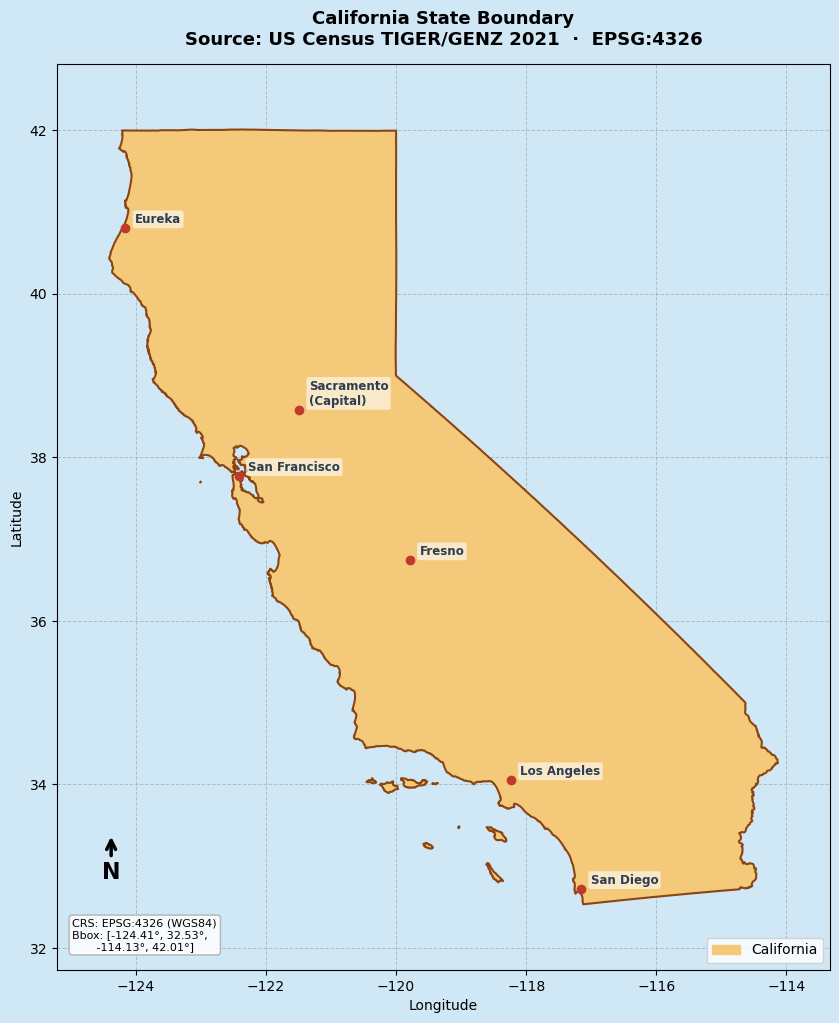

State plotted: California | CRS: epsg:4326 | Geometry: MultiPolygon


In [ ]:
# ============================================================
# California Boundary Shapefile - Plot
# ============================================================

# ─── CONFIG ──────────────────────────────────────────────────
CALSHAPE_PATH       = "ExtData/Calshape/California.shp"  # path to shapefile
STATE_NAME_FILTER   = "California"     # name of state to isolate from the file
                                       # change to e.g. "Oregon" to plot a different state

# ── Zoom & Layout ────────────────────────────────────────────
PADDING_DEG   = 0.8      # degrees of whitespace padding around state border
                         # lower = tighter zoom, higher = more surrounding ocean/states shown
FIGSIZE       = (8.5, 11)  # (width, height) in inches — 8.5x11 = standard page portrait

# ── Colors ───────────────────────────────────────────────────
FILL_COLOR    = "#f5c97a"   # state interior fill
EDGE_COLOR    = "#8B4513"   # state border color
EDGE_WIDTH    = 1.5         # state border line width
OCEAN_COLOR   = "#d0e8f5"   # background (ocean) color

# ── Optional Features (True/False) ───────────────────────────
SHOW_CITIES         = True   # plot and label city dots
SHOW_COMPASS        = True   # show north arrow
SHOW_GRIDLINES      = True   # show lat/lon grid
SHOW_LATLON_LABELS  = True   # show axis lat/lon tick labels
SHOW_CRS_BOX        = True   # show the CRS info box in corner
SHOW_LEGEND         = True   # show the color legend patch

# ── Title ────────────────────────────────────────────────────
TITLE_OVERRIDE = None
# Set to None to use the auto title, or override like:
# TITLE_OVERRIDE = "My Custom Map Title\nSubtitle here"

# ── Output ───────────────────────────────────────────────────
SAVE_PNG      = True
OUTPUT_FILE   = "plot_california_boundary.png"
# ─── END CONFIG ──────────────────────────────────────────────

import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# ── Load and FILTER to the target state ──────────────────────
gdf = gpd.read_file("/glade/u/home/jhana/m/IMP_fire_2026/ExtData/Calshape/California.shp")

# If the file has all 50 states, isolate the target state
if "NAME" in gdf.columns and len(gdf) > 1:
    state = gdf[gdf["NAME"] == STATE_NAME_FILTER].copy()
    if state.empty:
        raise ValueError(f"State '{STATE_NAME_FILTER}' not found. Available: {gdf['NAME'].tolist()}")
else:
    state = gdf.copy()  # already a single-state file

if state.crs is None or state.crs.to_epsg() != 4326:
    state = state.to_crs(epsg=4326)

# ── Compute zoom bounds from state geometry ───────────────────
bounds = state.total_bounds  # [minx, miny, maxx, maxy]
lon_min = bounds[0] - PADDING_DEG
lon_max = bounds[2] + PADDING_DEG
lat_min = bounds[1] - PADDING_DEG
lat_max = bounds[3] + PADDING_DEG

# ── Figure ────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=FIGSIZE, facecolor=OCEAN_COLOR)
ax.set_facecolor(OCEAN_COLOR)

state.plot(ax=ax, color=FILL_COLOR, edgecolor=EDGE_COLOR, linewidth=EDGE_WIDTH, zorder=2)

# ── Zoom to state ─────────────────────────────────────────────
ax.set_xlim(lon_min, lon_max)
ax.set_ylim(lat_min, lat_max)

# ── Cities ────────────────────────────────────────────────────
if SHOW_CITIES:
    cities = {
        "Los Angeles":       (-118.24, 34.05),
        "San Francisco":     (-122.42, 37.77),
        "Sacramento\n(Capital)": (-121.49, 38.58),
        "San Diego":         (-117.16, 32.72),
        "Fresno":            (-119.79, 36.74),
        "Eureka":            (-124.16, 40.80),
    }
    for name, (lon, lat) in cities.items():
        ax.plot(lon, lat, 'o', color='#c0392b', markersize=6, zorder=4)
        ax.annotate(name, xy=(lon, lat), xytext=(7, 4),
                    textcoords='offset points',
                    fontsize=8.5, color='#2c3e50', fontweight='bold',
                    bbox=dict(boxstyle='round,pad=0.2', fc='white', alpha=0.6, ec='none'))

# ── North Arrow ───────────────────────────────────────────────
if SHOW_COMPASS:
    ax.annotate('N', xy=(0.07, 0.15), xytext=(0.07, 0.10),
                arrowprops=dict(arrowstyle='->', color='black', lw=2.5),
                xycoords='axes fraction', textcoords='axes fraction',
                ha='center', fontsize=16, fontweight='bold')

# ── Gridlines ─────────────────────────────────────────────────
if SHOW_GRIDLINES:
    ax.grid(True, linestyle='--', alpha=0.4, color='gray', linewidth=0.7)

# ── Lat/Lon tick labels ───────────────────────────────────────
if not SHOW_LATLON_LABELS:
    ax.set_xticklabels([])
    ax.set_yticklabels([])
    ax.set_xlabel("")
    ax.set_ylabel("")
else:
    ax.set_xlabel("Longitude", fontsize=10)
    ax.set_ylabel("Latitude", fontsize=10)

# ── CRS Info Box ──────────────────────────────────────────────
if SHOW_CRS_BOX:
    props = dict(boxstyle='round', facecolor='white', alpha=0.85, edgecolor='#aaa')
    ax.text(0.02, 0.02,
            f"CRS: EPSG:4326 (WGS84)\n"
            f"Bbox: [{bounds[0]:.2f}°, {bounds[1]:.2f}°,\n"
            f"       {bounds[2]:.2f}°, {bounds[3]:.2f}°]",
            transform=ax.transAxes, fontsize=8,
            verticalalignment='bottom', bbox=props)

# ── Legend ────────────────────────────────────────────────────
if SHOW_LEGEND:
    patch = mpatches.Patch(color=FILL_COLOR, label=STATE_NAME_FILTER, edgecolor=EDGE_COLOR)
    ax.legend(handles=[patch], loc='lower right', fontsize=10)

# ── Title ─────────────────────────────────────────────────────
if TITLE_OVERRIDE:
    title_text = TITLE_OVERRIDE
else:
    title_text = (f"{STATE_NAME_FILTER} State Boundary\n"
                  f"Source: US Census TIGER/GENZ 2021  ·  EPSG:4326")
ax.set_title(title_text, fontsize=13, fontweight='bold', pad=14)

plt.tight_layout()

if SAVE_PNG:
    plt.savefig(OUTPUT_FILE, dpi=150, bbox_inches='tight')
    print(f"Saved: {OUTPUT_FILE}")
plt.show()
print(f"State plotted: {STATE_NAME_FILTER} | CRS: {state.crs} | Geometry: {state.geom_type.values[0]}")


**Great Job!**

## GridMET fm1000 (1000-hr Fuel Moisture) Download

Fires burn stuff, this data helps determine how burny the stuff is. 

Navigate to our extra data folder  
```cd /glade/derecho/scratch/$USER/IMP_fire_2026/ExtData```

Create GridMET folder  
```mkdir GridMET```  
  
Navigate to our GridMET folder  
```cd GridMET```  
  
```for y in {2012..2020};``` variable y, {} generates a list of strings, years between  
```do echo "Downloading $y"``` prints progress to screen of y variable    
```wget```  download from the following link     
```-c```  and if you get cut off allow continue once started again  
```ulr```   
```done``` to complete the command   

In [ ]:
for y in {2012..2020}; do echo "Downloading $y" wget -c https://www.northwestknowledge.net/metdata/data/fm1000_${y}.nc done

Verify our file contents.  
  
Check that the required variable exists:  
  
```ncdump```    NetCDF converts binary to CDL  
```-h```   header only  
```fm1000_2012.nc```  the input file  
``` |```  pipe send one command to the next, rather than printing output  
```grep dead_fuel_moisture_1000hr```  grep is the Ctrl+F of terminal, Global Regular Expression Print  
  
Expected variable output:   
  
```dead_fuel_moisture_1000hr```   result of the grep, only what is searched for  

In [ ]:
ncdump -h fm1000_2012.nc | grep dead_fuel_moisture_1000hr

In [4]:
%cd /glade/u/home/jhana/m/IMP_fire_2026/ExtData/Calshape
!ls

/glade/derecho/scratch/jhana/IMP_fire_2026/ExtData/Calshape
California.dbf		   cb_2021_us_state_500k.shp
California.prj		   cb_2021_us_state_500k.shp.ea.iso.xml
California.shp		   cb_2021_us_state_500k.shp.iso.xml
California.shx		   cb_2021_us_state_500k.shx
cb_2021_us_state_500k.cpg  cb_2021_us_state_500k.zip
cb_2021_us_state_500k.dbf  cb_2021_us_state_500k.zip.1
cb_2021_us_state_500k.prj  plot_california_boundary.png


Prepair to show fuel/moistre data

In [ ]:
# run these from terminal
# module load conda
# conda activate feds_py39     # you must be in the project kernel
# pip install netCDF4          # install missing NetCDF for xarray in the project kernel
# jupyter kernelspec list      # we must reload kernel, rejoining is easy
# conda activate myderecho_py
# conda activate feds_py39     # we are ready to show moisture data


/bin/bash: conda: command not found


## Here, we are Showing The Fuel/Moisture Data

A spatial heatmap of fuel moisture clipped to California for July 2018, plus a time-series line chart showing daily fuel moisture for the entire 2018 fire season, so we can see when conditions became dangerous.

Saved: plot_gridmet_map.png


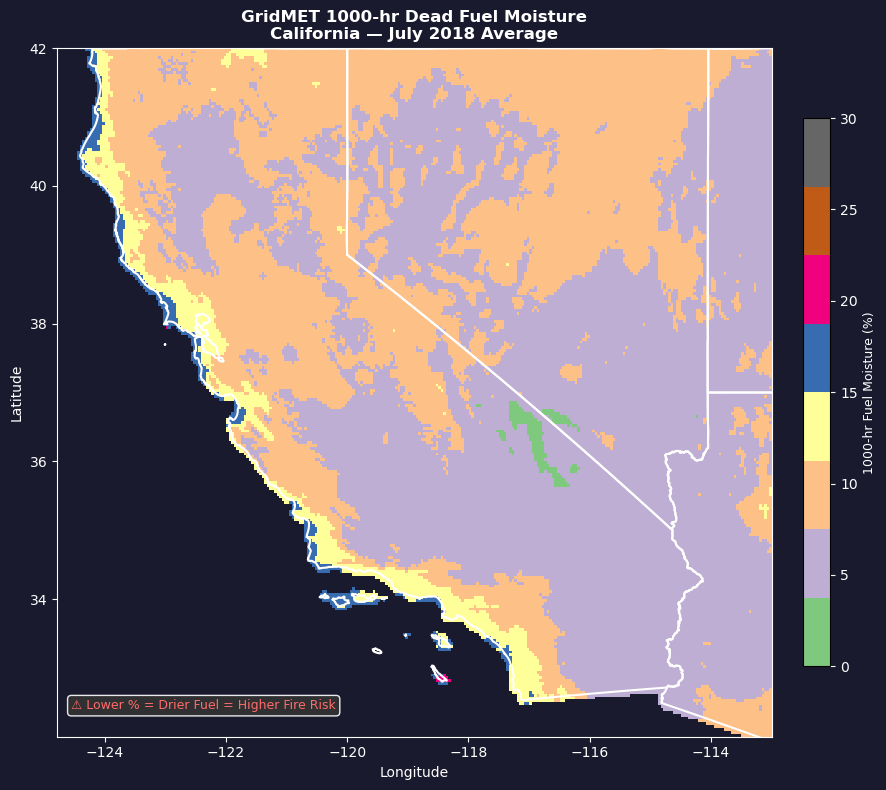

Saved: plot_gridmet_timeseries.png


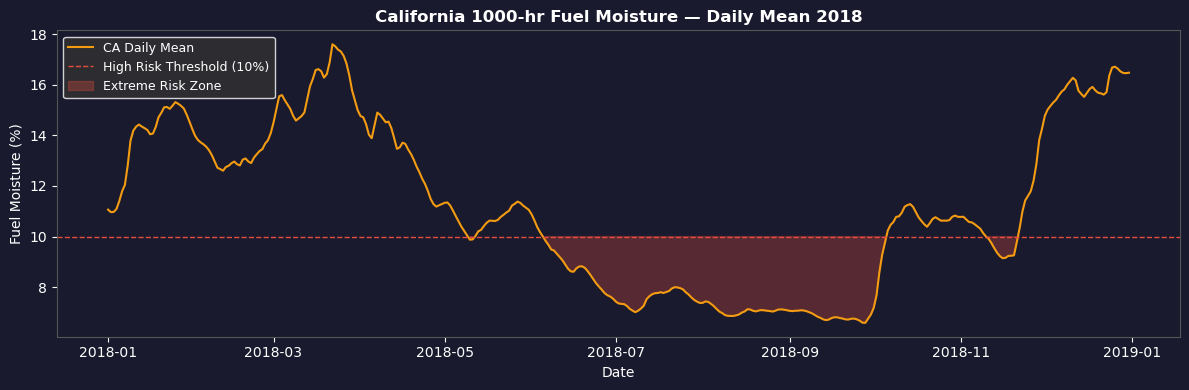

GridMET loaded | Variable: dead_fuel_moisture_1000hr


In [4]:
# ============================================================
# GridMET 1000-hr Fuel Moisture - Polt and Line Graph
# ============================================================

# --- CONFIG ---
GRIDMET_PATH  = "/glade/u/home/jhana/m/IMP_fire_2026/ExtData/GridMET/fm1000_2018.nc"   # GridMET NetCDF file
CALSHAPE_PATH = "/glade/u/home/jhana/m/IMP_fire_2026/ExtData/Calshape/California.shp"  # California boundary
PLOT_YEAR     = 2018                                # year to analyze
PLOT_MONTH    = 7                                   # month for the map (7 = July)
CA_BBOX       = (-125, 32, -113, 42)               # lon_min, lat_min, lon_max, lat_max
CMAP          = "Accent"
# CMAP          = "YlOrRd_r"                    # colormap (reversed: green=moist, red=dry)
SAVE_PNG      = True
OUTPUT_MAP    = "plot_gridmet_map.png"
OUTPUT_CHART  = "plot_gridmet_timeseries.png"
# --- END CONFIG ---

import xarray as xr
import numpy as np
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import pandas as pd

ca = gpd.read_file(CALSHAPE_PATH).to_crs(epsg=4326)

ds = xr.open_dataset(GRIDMET_PATH)
varname = "dead_fuel_moisture_1000hr"
da = ds[varname]

# Clip to California bounding box
lon_min, lat_min, lon_max, lat_max = CA_BBOX
da_ca = da.sel(lon=slice(lon_min, lon_max), lat=slice(lat_max, lat_min))

# --- FIGURE 1: Spatial map for the selected month ---
da_month = da_ca.sel(day=da_ca.day.dt.month == PLOT_MONTH).mean(dim='day')

fig, ax = plt.subplots(figsize=(9, 8), facecolor='#1a1a2e')
ax.set_facecolor('#1a1a2e')

im = da_month.plot(ax=ax, cmap=CMAP, add_colorbar=False, vmin=0, vmax=30)
cbar = plt.colorbar(im, ax=ax, fraction=0.035, pad=0.04)
cbar.set_label("1000-hr Fuel Moisture (%)", fontsize=9, color='white')
cbar.ax.yaxis.set_tick_params(color='white')
plt.setp(plt.getp(cbar.ax.axes, 'yticklabels'), color='white')

ca.boundary.plot(ax=ax, color='white', linewidth=1.5, zorder=3)

month_name = pd.Timestamp(f"{PLOT_YEAR}-{PLOT_MONTH:02d}-01").strftime("%B")
ax.set_title(f"GridMET 1000-hr Dead Fuel Moisture\nCalifornia — {month_name} {PLOT_YEAR} Average",
             color='white', fontsize=12, fontweight='bold')
ax.set_xlabel("Longitude", color='white'); ax.set_ylabel("Latitude", color='white')
ax.tick_params(colors='white')
for spine in ax.spines.values(): spine.set_edgecolor('white')

props = dict(boxstyle='round', facecolor='#333', alpha=0.9, edgecolor='white')
ax.text(0.02, 0.04,
        "⚠ Lower % = Drier Fuel = Higher Fire Risk",
        transform=ax.transAxes, fontsize=9, color='#ff6b6b', bbox=props)

plt.tight_layout()
if SAVE_PNG:
    plt.savefig(OUTPUT_MAP, dpi=150, bbox_inches='tight', facecolor='#1a1a2e')
    print(f"Saved: {OUTPUT_MAP}")
plt.show()

# --- FIGURE 2: Time-series line chart for full year ---
da_year = da_ca.sel(day=da_ca.day.dt.year == PLOT_YEAR)
ca_mean_daily = da_year.mean(dim=['lat', 'lon']).to_pandas()

fig2, ax2 = plt.subplots(figsize=(12, 4), facecolor='#1a1a2e')
ax2.set_facecolor('#1a1a2e')
ax2.plot(ca_mean_daily.index, ca_mean_daily.values, color='#f39c12', linewidth=1.5, label='CA Daily Mean')
ax2.axhline(y=10, color='#e74c3c', linestyle='--', linewidth=1, label='High Risk Threshold (10%)')
ax2.fill_between(ca_mean_daily.index, ca_mean_daily.values, 10,
                 where=(ca_mean_daily.values < 10), alpha=0.3, color='#e74c3c', label='Extreme Risk Zone')
ax2.set_title(f"California 1000-hr Fuel Moisture — Daily Mean {PLOT_YEAR}",
              color='white', fontsize=12, fontweight='bold')
ax2.set_xlabel("Date", color='white'); ax2.set_ylabel("Fuel Moisture (%)", color='white')
ax2.tick_params(colors='white')
ax2.legend(facecolor='#333', edgecolor='white', labelcolor='white', fontsize=9)
for spine in ax2.spines.values(): spine.set_edgecolor('#555')
plt.tight_layout()
if SAVE_PNG:
    plt.savefig(OUTPUT_CHART, dpi=150, bbox_inches='tight', facecolor='#1a1a2e')
    print(f"Saved: {OUTPUT_CHART}")
plt.show()
ds.close()
print(f"GridMET loaded | Variable: {varname}")


**Great Job!**

## NLCD 2016 Land Cover Setup (California)

We must prepare NLCD 2016 land cover raster for FEDS processing.

Navigate to our extra data folder  
```cd /glade/derecho/scratch/$USER/IMP_fire_2026/ExtData```  
  
Download our data   
```wget -c https://www.pasda.psu.edu/download/usgs/NLCD2016/NLCD_2016_Land_Cover_L48_20190424.zip```   
  
Unzip our file and check data  
```unzip NLCD_2016_Land_Cover_L48_20190424.zip```  

**Expected file:**  
nlcd_2016_land_cover_l48_20190424.img  

In [ ]:
wget -c https://www.pasda.psu.edu/download/usgs/NLCD2016/NLCD_2016_Land_Cover_L48_20190424.zip 

unzip NLCD_2016_Land_Cover_L48_20190424.zip

ls

Next, we will Convert NetCDF data into GeoTIFF.  
  
A GeoTIFF image file has tags in it and tells GIS software exactly where on Earth the pixels belong, coordinates, projection, and datum. Datum defines the size and shape of the Earth so that coordinates can be assigned to specific points on the surface, accounts for earths bumps.  
  
These next few operations take quite a bit of compute and time to complete.   
We will be using the ```screen``` command that is outlined in the **[Setup and File Checking](#setup-and-file-checking)** section above.  

First we clip roughly to California bbox (fast)  
  
```gdalwarp```  re-projecting, cropping, clipping, and resizing raster data   
```-te -125 32 -113 42```    Target Extent, bounding box min/max x/y  
```-te_srs EPSG:4326```   gdal know these are WGS 84 not meters  
```-r near```  Nearest Neighbor, keeps pixels from mixing by average, meaning without it pixel types are not honored     
```-dstnodata 0```  keeps the background of map clean and transparent in GIS  
```nlcd_full.tif nlcd_bbox.tif``` input and output files   

In [ ]:
screen -ls
screen scr_one
module load gdal
gdal_translate NLCD_2016_Land_Cover_L48_20190424.img nlcd_full.tif

# press ctrl+A ctrl+D  or ctrl+A ctrl+R 

gdalwarp
-te -125 32 -113 42
-te_srs EPSG:4326
-r near
-dstnodata 0
nlcd_full.tif nlcd_bbox.tif

Next we clip precisely to California boundary

```-cutline ./Calshape/California.shp```  Points to a vector file (Shapefile) to use as a stencil  
```-crop_to_cutline```  Trims to the bounding box  


In [ ]:
screen -ls
screen scr_two
# press ctrl+A ctrl+D  or ctrl+A ctrl+R 

gdalwarp
-cutline ./Calshape/California.shp
-crop_to_cutline
-dstnodata 0
-r near
nlcd_bbox.tif nlcd_CA.tif

Convert to FEDS expected format   
FEDS expects a lat/lon GeoTIFF named: nlcd_510m.tif   

In [ ]:
screen -ls
screen scr_three
# press ctrl+A ctrl+D  or ctrl+A ctrl+R 

gdalwarp
-t_srs EPSG:4326
-tr 0.005 0.005
-r near
nlcd_CA.tif nlcd_510m.tif

Verify our data  

```gdalinfo nlcd_510m.tif | grep EPSG gdalinfo nlcd_510m.tif | grep "Size is"```   

**Expected:**  
EPSG:4326  
Pixel size ~0.005 degree  

In [ ]:
gdalinfo nlcd_510m.tif | grep EPSG gdalinfo nlcd_510m.tif | grep "Size is"

Prepare to show land cover data

In [2]:
# ── Section 3 Pre-fix v2: hard bbox crop + mask to California ──
import rasterio
import rasterio.mask
import rasterio.windows
import geopandas as gpd
from shapely.geometry import box

NLCD_PATH     = "/glade/u/home/jhana/m/IMP_fire_2026/ExtData/nlcd_510m.tif"
CALSHAPE_PATH = "/glade/u/home/jhana/m/IMP_fire_2026/ExtData/Calshape/California.shp"
NLCD_CA_PATH  = "/glade/u/home/jhana/m/IMP_fire_2026/ExtData/nlcd_510m_CA.tif"

# Hard California bounding box — this forces the crop
CA_BBOX = (-124.5, 32.4, -114.0, 42.1)  # lon_min, lat_min, lon_max, lat_max

ca = gpd.read_file(CALSHAPE_PATH).to_crs(epsg=4326)

print("Cropping to California bbox and masking to state boundary...")

with rasterio.open(NLCD_PATH) as src:
    # Step 1: compute the pixel window for the CA bounding box
    bbox_geom = box(*CA_BBOX)
    window = rasterio.windows.from_bounds(
        *CA_BBOX,
        transform=src.transform
    )
    window = window.round_lengths().round_offsets()

    # Step 2: read only that window
    data = src.read(1, window=window)
    win_transform = rasterio.windows.transform(window, src.transform)

    # Step 3: write a temp-style dataset in memory and mask to CA shape
    from rasterio.io import MemoryFile
    from rasterio.mask import mask as rio_mask

    mem_meta = src.meta.copy()
    mem_meta.update({
        "height":    data.shape[0],
        "width":     data.shape[1],
        "transform": win_transform,
    })

    with MemoryFile() as memfile:
        with memfile.open(**mem_meta) as mem_ds:
            mem_ds.write(data, 1)
            out_image, out_transform = rio_mask(
                mem_ds, ca.geometry, crop=True, nodata=0
            )

    # Step 4: save the result
    out_meta = mem_meta.copy()
    out_meta.update({
        "height":    out_image.shape[1],
        "width":     out_image.shape[2],
        "transform": out_transform,
        "nodata":    0
    })

    with rasterio.open(NLCD_CA_PATH, "w", **out_meta) as dest:
        dest.write(out_image)

# Verify
with rasterio.open(NLCD_CA_PATH) as check:
    print(f"✅ Saved : {NLCD_CA_PATH}")
    print(f"   Size  : {check.width} x {check.height} pixels")
    print(f"   Bounds: {check.bounds}")
    print(f"   Pixel : {check.transform.a:.6f}°")
    print(f"   CRS   : {check.crs}")


Cropping to California bbox and masking to state boundary...
✅ Saved : /glade/u/home/jhana/m/IMP_fire_2026/ExtData/nlcd_510m_CA.tif
   Size  : 2100 x 1940 pixels
   Bounds: BoundingBox(left=-124.50499995171123, bottom=32.4, right=-114.00499995171123, top=42.1)
   Pixel : 0.005000°
   CRS   : EPSG:4326


Expected output:  
Size  : ~2200 x ~1900 pixels  
Bounds: left≈-124.4, bottom≈32.5, right≈-114.1, top≈42.0  
Pixel : 0.010000°  


## Here, we are showing the Land Cover Data
A color-coded land cover map of California using the official NLCD color scheme, plus a bar chart showing how many pixels (area) fall into each land cover class.

The NLCD L48 product covers the lower 48 contiguous US states, but it does not include data for the strip of northern California near the Oregon border or parts of the southern tip. Those areas are legitimately empty in this dataset.

Raster masked to California boundary
   Shape: (485, 525) | RAM: ~0.3 MB
   Extent: lon [-124.505 → -114.005]  lat [32.400 → 42.100]
Saved: plot_nlcd_map.png


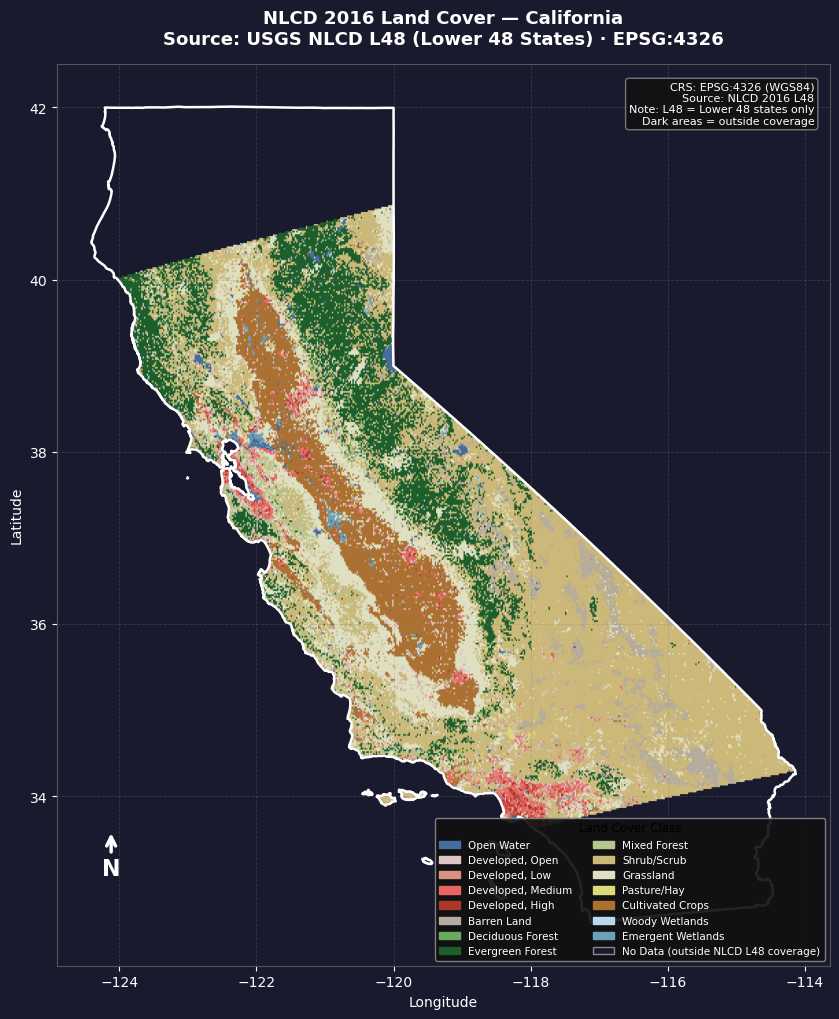

Saved: plot_nlcd_bar.png


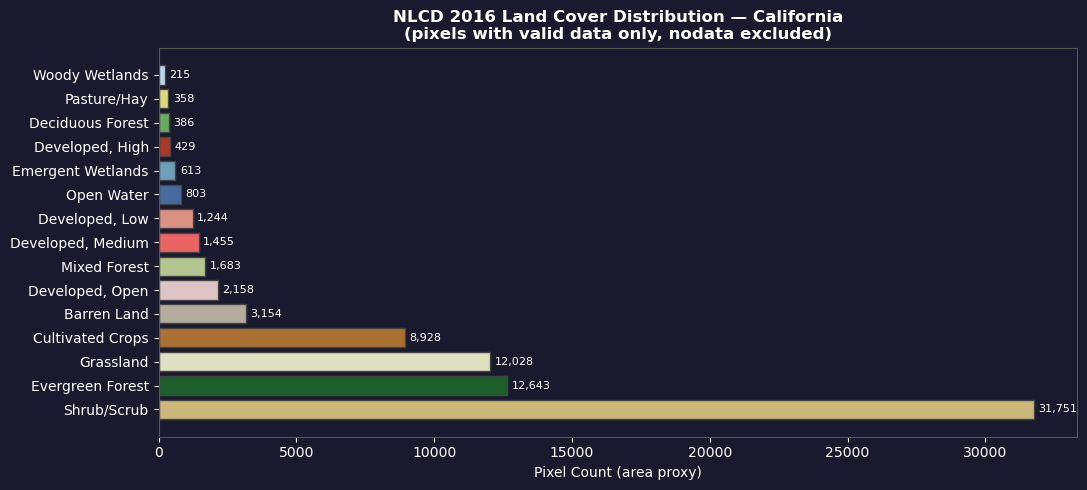

NLCD done | Shape: (485, 525) | Classes: 15


In [1]:
# ============================================================
# NLCD 2016 Land Cover (California)
# ============================================================

# ─── CONFIG ──────────────────────────────────────────────────
NLCD_PATH     = "/glade/u/home/jhana/m/IMP_fire_2026/ExtData/nlcd_510m_CA.tif"
CALSHAPE_PATH = "/glade/u/home/jhana/m/IMP_fire_2026/ExtData/Calshape/California.shp"

STATE_NAME_FILTER = "California"
PADDING_DEG       = 0.5
DOWNSAMPLE_FACTOR = 4
FIGSIZE_MAP       = (8.5, 11)
FIGSIZE_BAR       = (11, 5)
DARK_MODE         = True
SHOW_GRIDLINES      = True
SHOW_LATLON_LABELS  = True
SHOW_LEGEND         = True
SHOW_CRS_BOX        = True
TITLE_OVERRIDE      = None
SAVE_PNG    = True
OUTPUT_MAP  = "plot_nlcd_map.png"
OUTPUT_BAR  = "plot_nlcd_bar.png"
# ─── END CONFIG ──────────────────────────────────────────────

import rasterio
import rasterio.mask
from rasterio.enums import Resampling
from rasterio.io import MemoryFile
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import geopandas as gpd
from collections import Counter

BG = '#1a1a2e' if DARK_MODE else 'white'
TC = 'white'   if DARK_MODE else 'black'
NODATA_COLOR = np.array([13, 13, 30], dtype=np.uint8)  # matches dark background — invisible nodata

NLCD_LEGEND = {
    11: ((70,  107, 159), "Open Water"),
    21: ((222, 197, 197), "Developed, Open"),
    22: ((217, 146, 130), "Developed, Low"),
    23: ((235, 100, 100), "Developed, Medium"),
    24: ((171,  56,  40), "Developed, High"),
    31: ((179, 172, 159), "Barren Land"),
    41: ((104, 171,  95), "Deciduous Forest"),
    42: ((28,   95,  44), "Evergreen Forest"),
    43: ((181, 197, 143), "Mixed Forest"),
    52: ((204, 184, 121), "Shrub/Scrub"),
    71: ((223, 223, 194), "Grassland"),
    81: ((220, 217, 123), "Pasture/Hay"),
    82: ((171, 113,  50), "Cultivated Crops"),
    90: ((184, 217, 235), "Woody Wetlands"),
    95: ((108, 159, 184), "Emergent Wetlands"),
}

# ── Load shapefile ────────────────────────────────────────────
gdf = gpd.read_file(CALSHAPE_PATH).to_crs(epsg=4326)
ca  = gdf[gdf["NAME"] == STATE_NAME_FILTER].copy() \
      if "NAME" in gdf.columns and len(gdf) > 1 else gdf.copy()
bounds  = ca.total_bounds
lon_min = bounds[0] - PADDING_DEG
lon_max = bounds[2] + PADDING_DEG
lat_min = bounds[1] - PADDING_DEG
lat_max = bounds[3] + PADDING_DEG

# ── Read raster AND mask to exact California polygon ──────────
# This clips pixels outside the state boundary to nodata
# so the raster matches the shapefile shape exactly
with rasterio.open(NLCD_PATH) as src:
    full_h, full_w = src.height, src.width

    # Mask to California polygon — pixels outside = 0
    masked_data, masked_transform = rasterio.mask.mask(
        src, ca.geometry, crop=False, nodata=0, filled=True
    )
    data_full = masked_data[0]  # single band

    # Downsample for memory safety
    out_h = full_h // DOWNSAMPLE_FACTOR
    out_w = full_w // DOWNSAMPLE_FACTOR

    # Write masked data to memory file and read back downsampled
    mem_meta = src.meta.copy()
    mem_meta.update({"transform": masked_transform, "nodata": 0})

    with MemoryFile() as memfile:
        with memfile.open(**mem_meta) as mem_ds:
            mem_ds.write(data_full, 1)
            data = mem_ds.read(
                1,
                out_shape=(out_h, out_w),
                resampling=Resampling.nearest
            )
            t = mem_ds.transform

    # Compute pixel-EDGE extent from scaled transform
    scaled_a = t.a * (full_w / out_w)
    scaled_e = t.e * (full_h / out_h)
    img_left   = t.c
    img_top    = t.f
    img_right  = t.c + scaled_a * out_w
    img_bottom = t.f + scaled_e * out_h

print(f"Raster masked to {STATE_NAME_FILTER} boundary")
print(f"   Shape: {data.shape} | RAM: ~{data.nbytes/1e6:.1f} MB")
print(f"   Extent: lon [{img_left:.3f} → {img_right:.3f}]  lat [{img_bottom:.3f} → {img_top:.3f}]")

# ── Build RGB — nodata pixels blend into background ──────────
rgb = np.full((*data.shape, 3), NODATA_COLOR, dtype=np.uint8)
for val, (color, _) in NLCD_LEGEND.items():
    rgb[data == val] = color

# Create alpha channel — nodata pixels are transparent
alpha = np.where(data == 0, 0, 255).astype(np.uint8)
rgba  = np.dstack([rgb, alpha])

# ── FIGURE 1: Land Cover Map ──────────────────────────────────
fig, ax = plt.subplots(figsize=FIGSIZE_MAP, facecolor=BG)
ax.set_facecolor(BG)

extent = [img_left, img_right, img_bottom, img_top]
ax.imshow(rgba, extent=extent, aspect='auto', origin='upper', zorder=1)

# State border on top
ca.boundary.plot(ax=ax, color='white', linewidth=1.8, zorder=3)

ax.set_xlim(lon_min, lon_max)
ax.set_ylim(lat_min, lat_max)

# ── Legend ────────────────────────────────────────────────────
if SHOW_LEGEND:
    present = [v for v in NLCD_LEGEND if np.any(data == v)]
    patches = [mpatches.Patch(color=np.array(NLCD_LEGEND[v][0])/255,
                               label=NLCD_LEGEND[v][1]) for v in present]

    # FIX: pass the hex string directly, not through np.array()
    patches.append(mpatches.Patch(
        facecolor=BG,
        edgecolor='#888888',
        linewidth=1,
        label="No Data (outside NLCD L48 coverage)"
    ))

    ax.legend(handles=patches, loc='lower right', fontsize=7.5,
              facecolor='#111' if DARK_MODE else 'white',
              edgecolor='#888', labelcolor=TC, ncol=2,
              title="Land Cover Class", title_fontsize=8.5,
              framealpha=0.92)

# ── North Arrow (compass) ─────────────────────────────────────
ax.annotate('N', xy=(0.07, 0.15), xytext=(0.07, 0.10),
            arrowprops=dict(arrowstyle='->', color=TC, lw=2.5),
            xycoords='axes fraction', textcoords='axes fraction',
            ha='center', fontsize=16, fontweight='bold', color=TC)

# ── CRS Info Box ──────────────────────────────────────────────
if SHOW_CRS_BOX:
    props = dict(boxstyle='round', facecolor='#111' if DARK_MODE else 'white',
                 alpha=0.85, edgecolor='#888')
    ax.text(0.98, 0.98,
            f"CRS: EPSG:4326 (WGS84)\n"
            f"Source: NLCD 2016 L48\n"
            f"Note: L48 = Lower 48 states only\n"
            f"Dark areas = outside coverage",
            transform=ax.transAxes, fontsize=8,
            verticalalignment='top', horizontalalignment='right',
            bbox=props, color=TC)

if SHOW_GRIDLINES:
    ax.grid(True, linestyle='--', alpha=0.3, color='gray', linewidth=0.6)

if SHOW_LATLON_LABELS:
    ax.set_xlabel("Longitude", color=TC, fontsize=10)
    ax.set_ylabel("Latitude",  color=TC, fontsize=10)
else:
    ax.set_xticklabels([]); ax.set_yticklabels([])
    ax.set_xlabel(""); ax.set_ylabel("")

ax.tick_params(colors=TC)
for s in ax.spines.values(): s.set_edgecolor('#555')

title_text = TITLE_OVERRIDE if TITLE_OVERRIDE else \
    f"NLCD 2016 Land Cover — {STATE_NAME_FILTER}\nSource: USGS NLCD L48 (Lower 48 States) · EPSG:4326"
ax.set_title(title_text, color=TC, fontsize=13, fontweight='bold', pad=14)

plt.tight_layout()
if SAVE_PNG:
    plt.savefig(OUTPUT_MAP, dpi=150, bbox_inches='tight', facecolor=BG)
    print(f"Saved: {OUTPUT_MAP}")
plt.show()

# ── FIGURE 2: Bar Chart ───────────────────────────────────────
counts = Counter(data[data > 0].flatten())
valid  = [(v, counts[v]) for v in counts if v in NLCD_LEGEND]
valid.sort(key=lambda x: x[1], reverse=True)
vals = [x[1] for x in valid]
lbls = [NLCD_LEGEND[x[0]][1] for x in valid]
clrs = [np.array(NLCD_LEGEND[x[0]][0])/255 for x in valid]

fig2, ax2 = plt.subplots(figsize=FIGSIZE_BAR, facecolor=BG)
ax2.set_facecolor(BG)
bars = ax2.barh(lbls, vals, color=clrs, edgecolor='#444')
ax2.set_xlabel("Pixel Count (area proxy)", color=TC)
ax2.set_title(f"NLCD 2016 Land Cover Distribution — {STATE_NAME_FILTER}\n"
              f"(pixels with valid data only, nodata excluded)",
              color=TC, fontsize=12, fontweight='bold')
ax2.tick_params(colors=TC)
for s in ax2.spines.values(): s.set_edgecolor('#555')
for bar, val in zip(bars, vals):
    ax2.text(bar.get_width() + max(vals)*0.005,
             bar.get_y() + bar.get_height()/2,
             f'{val:,}', va='center', color=TC, fontsize=8)

plt.tight_layout()
if SAVE_PNG:
    plt.savefig(OUTPUT_BAR, dpi=150, bbox_inches='tight', facecolor=BG)
    print(f"Saved: {OUTPUT_BAR}")
plt.show()
print(f"NLCD done | Shape: {data.shape} | Classes: {len(valid)}")


**Great Job!**

## VIIRS VNP14IMGML Download (2012–2020)

Download VIIRS satellite active fire monthly ASCII data.  
VNP14IMGML Collection 1 (C01)   
  
Version numbers are an important note here, we want C01.04 collection 01 version 04.  
When you run this code they maybe different than what is noted in this section as these file are updated.  
The *Chen2022* paper states where the files are located, this is no longer the case, they can be found at the UMD server here:  
  
```fuoco.geog.umd.edu```
  
Login: fire  
Password: burnt  

Navigate to our extra data folder  
```cd /glade/derecho/scratch/$USER/IMP_fire_2026/ExtData```  

Create the VNP14IMGML04 folder  
```mkdir VNP14IMGML04```

Navigate to our VNP14IMGML04 folder  
```cd /glade/derecho/scratch/$USER/IMP_fire_2026/ExtData/VNP14IMGML04```

Join the server to retrieve our data    
```sftp fire@fuoco.geog.umd.edu```  

Enter password when prompted and you should be at ```sftp>```  :

In [ ]:
cd /glade/derecho/scratch/$USER/IMP_fire_2026/ExtData/VNP14IMGML04

sftp fire@fuoco.geog.umd.edu

SyntaxError: invalid syntax (2044480744.py, line 1)

Navigate to the correct folder  
You are looking for:  
**C1/VNP14IMGML/**   
  
```ls```   
```cd data```   
```ls```   
```cd VIIRS```  
```ls```  
```cd C1```  
```ls```  
```cd VNP14IMGML```  
```ls```  this one will be long  
```lpwd```  check your working directory
You are looking specifically for 'Collection 1.04' (C1.04), used in *Chen2022* paper, but the version (04) may have been updated, adjust these codes for the newer version.  
  
Once in the correct folder, you should see files like **VNP14IMGML.2012.C1.04.txt.gz**    

In [ ]:
ls 
cd data
ls 
cd VIIRS
ls
cd C1
ls
cd VNP14IMGML
ls 
lpwd 

We will use mget to retrieve years 2012-2020    
```mget VNP14IMGML.201*.C1.04.txt.gz```  this will take a few mins, can't screen on an sftp server  
```mget VNP14IMGML.2020*.C1.04.txt.gz``` this one is not as long 

Once complete 'bye' to exit  
```bye```

Check your files  
```ls```     
```echo $(((2021-2012) * 12))```  12 for each year 2012-2020 is 9 * 12 = 108   
```ls | wc -l```  count the files 

In [ ]:
mget VNP14IMGML.201*.C1.05.txt.gz 
mget VNP14IMGML.2020*.C1.05.txt.gz  

# To exit:  
# bye  

In [ ]:
ls
echo $(((2021-2012) * 12))
ls | wc -l

These text files contain many columns of data.  
Columns of interest from these files:  

**YYYYMMDD:** The calendar date of the satellite overpass.  
**HHMM:** The time of the overpass in Coordinated Universal Time (UTC).  
**Satellite:** Identifies which satellite detected the fire, Terra (morning/night overpass) or Aqua (afternoon/night overpass).  
**Latitude / Longitude:** The geographic coordinates of the **center** of the 1km x 1km pixel flagged as an active fire.  
**FRP:** (Fire Radiative Power) The rate of radiant energy released by the fire at the moment of detection, measured in **Megawatts (MW)**.  
**Radiative Power:** The specific spectral radiance used to calculate the energy output.  
**Confidence:** A percentage (0–100%) indicating the algorithm's "certainty" the pixel is a fire. Filter false alarms from sun glint or hot surfaces.  
**Land Cover:** Type of vegetation or terrain at that location, MODIS Land Cover Type product.   

Look at one of the files without unpacking with zip-less   
```zless VNP14IMGML.201201.C1.05.txt.gz```   

See the headers at the top, use arrow keys and pg Up/Dn  
```h```  for more commands,   
```q```  to quit   

In [ ]:
zless VNP14IMGML.201201.C1.05.txt.gz  

We will need to rename the files using this Magic.  
```%%bash``` 
 
```renamed=0```   Initialize counters  
```unchanged=0```  
  
```for file in VNP14IMGML.*.C1.05.txt.gz; do```  Loop through all matching files in the current directory   
```if [[ -e "$file" ]]; then```  Check if any files actually match the pattern to avoid errors    
```new_name="${file//.C1.05./.C1.04.}"```  generate the new name by replacing .C1.05. with .C1.04.   
```mv -- "$file" "$new_name"```   perform the rename   
```((renamed++))```  
```fi```  
```done```  
  
```for file in VNP14IMGML.*.C1.04.txt.gz; do ```  count files that didn't need renaming (already .C1.04. or other)  
```[[ -e "$file" ]] && ((unchanged_temp++))```  this looks for the "target" pattern to see how many exist now  
```done```  
  
```unchanged=$((unchanged_temp - renamed))```  calculate total unchanged by subtracting the ones we just renamed    
  
```echo "$renamed files renamed, $unchanged files unchanged"```  print the final summary   

In [17]:
!whoami
%cd /glade/derecho/scratch/jhana/IMP_fire_2026/ExtData/VNP14IMGML04
%ls


jhana


/glade/derecho/scratch/jhana/IMP_fire_2026/ExtData/VNP14IMGML04
d                               VNP14IMGML.201607.C1.05.txt.gz
VNP14IMGML.201201.C1.05.txt.gz  VNP14IMGML.201608.C1.05.txt.gz
VNP14IMGML.201202.C1.05.txt.gz  VNP14IMGML.201609.C1.05.txt.gz
VNP14IMGML.201203.C1.05.txt.gz  VNP14IMGML.201610.C1.05.txt.gz
VNP14IMGML.201204.C1.05.txt.gz  VNP14IMGML.201611.C1.05.txt.gz
VNP14IMGML.201205.C1.05.txt.gz  VNP14IMGML.201612.C1.05.txt.gz
VNP14IMGML.201206.C1.05.txt.gz  VNP14IMGML.201701.C1.05.txt.gz
VNP14IMGML.201207.C1.05.txt.gz  VNP14IMGML.201702.C1.05.txt.gz
VNP14IMGML.201208.C1.05.txt.gz  VNP14IMGML.201703.C1.05.txt.gz
VNP14IMGML.201209.C1.05.txt.gz  VNP14IMGML.201704.C1.05.txt.gz
VNP14IMGML.201210.C1.05.txt.gz  VNP14IMGML.201705.C1.05.txt.gz
VNP14IMGML.201211.C1.05.txt.gz  VNP14IMGML.201706.C1.05.txt.gz
VNP14IMGML.201212.C1.05.txt.gz  VNP14IMGML.201707.C1.05.txt.gz
VNP14IMGML.201301.C1.05.txt.gz  VNP14IMGML.201708.C1.05.txt.gz
VNP14IMGML.201302.C1.05.txt.gz  VNP14IMGML.201709.C1.0

In [18]:
%%bash

renamed=0
unchanged_temp=0

for file in VNP14IMGML.*.C1.05.txt.gz; do
    if [[ -e "$file" ]]; then
        new_name="${file//.C1.05./.C1.04.}"
        mv -- "$file" "$new_name"
        ((renamed++))
    fi
done

for file in VNP14IMGML.*.C1.04.txt.gz; do
    [[ -e "$file" ]] && ((unchanged_temp++))
done

unchanged=$((unchanged_temp - renamed))
echo "$renamed files renamed, $unchanged files unchanged"


108 files renamed, 0 files unchanged


In [19]:
!ls

d				VNP14IMGML.201607.C1.04.txt.gz
VNP14IMGML.201201.C1.04.txt.gz	VNP14IMGML.201608.C1.04.txt.gz
VNP14IMGML.201202.C1.04.txt.gz	VNP14IMGML.201609.C1.04.txt.gz
VNP14IMGML.201203.C1.04.txt.gz	VNP14IMGML.201610.C1.04.txt.gz
VNP14IMGML.201204.C1.04.txt.gz	VNP14IMGML.201611.C1.04.txt.gz
VNP14IMGML.201205.C1.04.txt.gz	VNP14IMGML.201612.C1.04.txt.gz
VNP14IMGML.201206.C1.04.txt.gz	VNP14IMGML.201701.C1.04.txt.gz
VNP14IMGML.201207.C1.04.txt.gz	VNP14IMGML.201702.C1.04.txt.gz
VNP14IMGML.201208.C1.04.txt.gz	VNP14IMGML.201703.C1.04.txt.gz
VNP14IMGML.201209.C1.04.txt.gz	VNP14IMGML.201704.C1.04.txt.gz
VNP14IMGML.201210.C1.04.txt.gz	VNP14IMGML.201705.C1.04.txt.gz
VNP14IMGML.201211.C1.04.txt.gz	VNP14IMGML.201706.C1.04.txt.gz
VNP14IMGML.201212.C1.04.txt.gz	VNP14IMGML.201707.C1.04.txt.gz
VNP14IMGML.201301.C1.04.txt.gz	VNP14IMGML.201708.C1.04.txt.gz
VNP14IMGML.201302.C1.04.txt.gz	VNP14IMGML.201709.C1.04.txt.gz
VNP14IMGML.201303.C1.04.txt.gz	VNP14IMGML.201710.C1.04.txt.gz
VNP14IMGML.201304.C1.04.txt.gz	VNP

Prepare to show the VIIRS active fire data

In [8]:
# ── Section 4 Diagnostic — check what VIIRS files exist ──────
import os

VIIRS_DIR = "/glade/u/home/jhana/m/IMP_fire_2026/ExtData/VNP14IMGML04/"

if not os.path.exists(VIIRS_DIR):
    print(f"❌ Directory does not exist: {VIIRS_DIR}")
else:
    files = sorted(os.listdir(VIIRS_DIR))
    print(f"✅ Directory found: {VIIRS_DIR}")
    print(f"   Total files: {len(files)}\n")
    print("All files:")
    for f in files:
        print(f"   {f}")


✅ Directory found: /glade/u/home/jhana/m/IMP_fire_2026/ExtData/VNP14IMGML04/
   Total files: 110

All files:
   .ipynb_checkpoints
   VNP14IMGML.201201.C1.04.txt.gz
   VNP14IMGML.201202.C1.04.txt.gz
   VNP14IMGML.201203.C1.04.txt.gz
   VNP14IMGML.201204.C1.04.txt.gz
   VNP14IMGML.201205.C1.04.txt.gz
   VNP14IMGML.201206.C1.04.txt.gz
   VNP14IMGML.201207.C1.04.txt.gz
   VNP14IMGML.201208.C1.04.txt.gz
   VNP14IMGML.201209.C1.04.txt.gz
   VNP14IMGML.201210.C1.04.txt.gz
   VNP14IMGML.201211.C1.04.txt.gz
   VNP14IMGML.201212.C1.04.txt.gz
   VNP14IMGML.201301.C1.04.txt.gz
   VNP14IMGML.201302.C1.04.txt.gz
   VNP14IMGML.201303.C1.04.txt.gz
   VNP14IMGML.201304.C1.04.txt.gz
   VNP14IMGML.201305.C1.04.txt.gz
   VNP14IMGML.201306.C1.04.txt.gz
   VNP14IMGML.201307.C1.04.txt.gz
   VNP14IMGML.201308.C1.04.txt.gz
   VNP14IMGML.201309.C1.04.txt.gz
   VNP14IMGML.201310.C1.04.txt.gz
   VNP14IMGML.201311.C1.04.txt.gz
   VNP14IMGML.201312.C1.04.txt.gz
   VNP14IMGML.201401.C1.04.txt.gz
   VNP14IMGML.20140

## Here, We Are Showing the VIIRS Active Fire data for CA Summer 2018
Fire detection points overlaid on the California map for July 2018, colored and sized by FRP (brighter/larger = more intense fire), plus a time-series of daily fire detections and total FRP for the month.

In [9]:
# ============================================================
# SECTION 4 VISUALIZATION — VIIRS Active Fire Detections
# ============================================================

# ─── CONFIG ──────────────────────────────────────────────────
VIIRS_DIR     = "/glade/u/home/jhana/m/IMP_fire_2026/ExtData/VNP14IMGML04/"
CALSHAPE_PATH = "/glade/u/home/jhana/m/IMP_fire_2026/ExtData/Calshape/California.shp"

# ── Data Selection ────────────────────────────────────────────
PLOT_YEAR      = 2018         # year to visualize
PLOT_MONTH     = 7            # month to visualize (7 = July)
VERSION        = "C1.04"      # file version string — adjust if your files differ

# ── File Delimiter ────────────────────────────────────────────
FILE_DELIMITER = "\t"         # try "\t" first (tab), then "," if columns don't load

# ── Filtering ─────────────────────────────────────────────────
MIN_CONFIDENCE = 50           # drop detections below this confidence %
FRP_PERCENTILE_CAP = 98       # cap FRP color scale at this percentile (reduces outlier blow-out)

# ── State Focus & Zoom (same system as Sections 1 & 3) ───────
STATE_NAME_FILTER = "California"
PADDING_DEG       = 0.5       # degrees of padding around state border

# ── Display ───────────────────────────────────────────────────
FIGSIZE_MAP   = (8.5, 11)     # portrait page — fire map
FIGSIZE_CHART = (12, 6)       # daily activity chart
DARK_MODE     = True

# ── Optional Features ────────────────────────────────────────
SHOW_GRIDLINES     = True
SHOW_LATLON_LABELS = True
SHOW_STATS_BOX     = True     # show total FRP / detection count box on map
SHOW_COMPASS       = True
TITLE_OVERRIDE     = None     # None = auto title, or set a string

# ── Output ───────────────────────────────────────────────────
SAVE_PNG       = True
OUTPUT_MAP     = "plot_viirs_fire_map.png"
OUTPUT_CHART   = "plot_viirs_daily_chart.png"
# ─── END CONFIG ──────────────────────────────────────────────

import gzip, os
import pandas as pd
import geopandas as gpd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

BG = '#0a0a0a' if DARK_MODE else 'white'
TC = 'white'   if DARK_MODE else 'black'

# ── Load & filter shapefile ───────────────────────────────────
gdf = gpd.read_file(CALSHAPE_PATH).to_crs(epsg=4326)
ca  = gdf[gdf["NAME"] == STATE_NAME_FILTER].copy() if "NAME" in gdf.columns and len(gdf) > 1 else gdf.copy()
bounds  = ca.total_bounds
lon_min = bounds[0] - PADDING_DEG
lon_max = bounds[2] + PADDING_DEG
lat_min = bounds[1] - PADDING_DEG
lat_max = bounds[3] + PADDING_DEG

# ── Build file path ───────────────────────────────────────────
fname = f"VNP14IMGML.{PLOT_YEAR}{PLOT_MONTH:02d}.{VERSION}.txt.gz"
fpath = os.path.join(VIIRS_DIR, fname)
print(f"Loading: {fpath}")
if not os.path.exists(fpath):
    raise FileNotFoundError(
        f"File not found: {fpath}\n"
        f"Check VIIRS_DIR, PLOT_YEAR, PLOT_MONTH, and VERSION in the config."
    )

# ── Load file ─────────────────────────────────────────────────
with gzip.open(fpath, 'rt') as f:
    df = pd.read_csv(f, sep=FILE_DELIMITER, low_memory=False)

df.columns = [c.strip() for c in df.columns]  # strip any whitespace from headers
print(f"Columns found ({len(df.columns)}): {df.columns.tolist()}")
print(f"Rows loaded: {len(df):,}")

# ── Robust column finder ──────────────────────────────────────
def find_col(df, *keywords):
    """Find first column whose name contains any keyword (case-insensitive)."""
    for kw in keywords:
        matches = [c for c in df.columns if kw.lower() in c.lower()]
        if matches:
            return matches[0]
    raise KeyError(
        f"Could not find a column matching any of: {keywords}\n"
        f"Available columns: {df.columns.tolist()}\n"
        f"Tip: check FILE_DELIMITER in config — try ',' if using tab gives one column."
    )

lon_c  = find_col(df, 'lon')
lat_c  = find_col(df, 'lat')
frp_c  = find_col(df, 'frp', 'radiative', 'fire_rad', 'power')
conf_c = find_col(df, 'conf')
date_c = find_col(df, 'yyyymmdd', 'acq_date', 'date')

print(f"\nMatched columns:")
print(f"  lon  → '{lon_c}'")
print(f"  lat  → '{lat_c}'")
print(f"  FRP  → '{frp_c}'")
print(f"  conf → '{conf_c}'")
print(f"  date → '{date_c}'")

df = df.rename(columns={lon_c:'lon', lat_c:'lat', frp_c:'FRP', conf_c:'Conf', date_c:'Date'})

# ── Clean & parse ─────────────────────────────────────────────
df['FRP']  = pd.to_numeric(df['FRP'],  errors='coerce')
df['Conf'] = pd.to_numeric(df['Conf'], errors='coerce')
df['lon']  = pd.to_numeric(df['lon'],  errors='coerce')
df['lat']  = pd.to_numeric(df['lat'],  errors='coerce')
df['Date'] = pd.to_datetime(df['Date'].astype(str), format='%Y%m%d', errors='coerce')
df = df.dropna(subset=['lon', 'lat', 'FRP', 'Date'])

# ── Filter to California bbox + confidence ────────────────────
df_ca = df[
    (df['lon']  >= lon_min) & (df['lon']  <= lon_max) &
    (df['lat']  >= lat_min) & (df['lat']  <= lat_max) &
    (df['Conf'] >= MIN_CONFIDENCE)
].copy()

print(f"\n After CA bbox + confidence filter: {len(df_ca):,} detections")
if len(df_ca) == 0:
    raise ValueError(
        "No detections remain after filtering. "
        "Try lowering MIN_CONFIDENCE or check CA_BBOX matches your data extent."
    )

# ── FRP color scale ───────────────────────────────────────────
frp_cap  = np.percentile(df_ca['FRP'], FRP_PERCENTILE_CAP)
frp_vals = df_ca['FRP'].clip(upper=frp_cap)
norm     = mcolors.PowerNorm(gamma=0.4, vmin=frp_vals.min(), vmax=frp_vals.max())
sizes    = 8 + 60 * norm(frp_vals)
month_name = pd.Timestamp(f"{PLOT_YEAR}-{PLOT_MONTH:02d}-01").strftime("%B")

# ── FIGURE 1: Fire Detection Map ─────────────────────────────
fig, ax = plt.subplots(figsize=FIGSIZE_MAP, facecolor=BG)
ax.set_facecolor(BG)

ca.plot(ax=ax, color='#1a2a1a', edgecolor='#666', linewidth=1.2, zorder=1)
sc = ax.scatter(
    df_ca['lon'], df_ca['lat'],
    c=frp_vals, cmap='inferno', norm=norm,
    s=sizes, alpha=0.85, linewidths=0, zorder=3
)

# Colorbar
cbar = plt.colorbar(sc, ax=ax, fraction=0.035, pad=0.04)
cbar.set_label("Fire Radiative Power (MW)", color=TC, fontsize=9)
cbar.ax.yaxis.set_tick_params(color=TC)
plt.setp(plt.getp(cbar.ax.axes, 'yticklabels'), color=TC)

# Zoom to California
ax.set_xlim(lon_min, lon_max)
ax.set_ylim(lat_min, lat_max)

# Stats box
if SHOW_STATS_BOX:
    props = dict(boxstyle='round', facecolor='#111' if DARK_MODE else 'white',
                 alpha=0.88, edgecolor='#ff4500')
    ax.text(
        0.02, 0.04,
        f"Detections : {len(df_ca):,}\n"
        f"Total FRP  : {df_ca['FRP'].sum():,.0f} MW\n"
        f"Max FRP    : {df_ca['FRP'].max():,.0f} MW\n"
        f"Confidence : ≥{MIN_CONFIDENCE}%",
        transform=ax.transAxes, fontsize=9,
        verticalalignment='bottom', color='#ff9944', bbox=props
    )

# North arrow
if SHOW_COMPASS:
    ax.annotate('N', xy=(0.07, 0.15), xytext=(0.07, 0.10),
                arrowprops=dict(arrowstyle='->', color=TC, lw=2.5),
                xycoords='axes fraction', textcoords='axes fraction',
                ha='center', fontsize=16, fontweight='bold', color=TC)

# Gridlines
if SHOW_GRIDLINES:
    ax.grid(True, linestyle='--', alpha=0.25, color='gray', linewidth=0.6)

# Axis labels
if SHOW_LATLON_LABELS:
    ax.set_xlabel("Longitude", color=TC, fontsize=10)
    ax.set_ylabel("Latitude",  color=TC, fontsize=10)
else:
    ax.set_xticklabels([]); ax.set_yticklabels([])
    ax.set_xlabel(""); ax.set_ylabel("")

ax.tick_params(colors=TC)
for s in ax.spines.values(): s.set_edgecolor('#555')

title_text = TITLE_OVERRIDE if TITLE_OVERRIDE else \
    f"VIIRS Active Fire Detections — {STATE_NAME_FILTER}\n{month_name} {PLOT_YEAR}  ·  VNP14IMGML {VERSION}  ·  EPSG:4326"
ax.set_title(title_text, color=TC, fontsize=12, fontweight='bold', pad=14)

plt.tight_layout()
if SAVE_PNG:
    plt.savefig(OUTPUT_MAP, dpi=150, bbox_inches='tight', facecolor=BG)
    print(f"Saved: {OUTPUT_MAP}")
plt.show()

# ── FIGURE 2: Daily Activity Chart ───────────────────────────
daily = df_ca.groupby('Date').agg(
    Count=('FRP', 'count'),
    TotalFRP=('FRP', 'sum'),
    MaxFRP=('FRP', 'max')
).reset_index()

fig2, (ax_top, ax_bot) = plt.subplots(
    2, 1, figsize=FIGSIZE_CHART, facecolor=BG, sharex=True,
    gridspec_kw={'hspace': 0.08}
)
for ax in [ax_top, ax_bot]:
    ax.set_facecolor(BG)
    for s in ax.spines.values(): s.set_edgecolor('#444')
    ax.tick_params(colors=TC)

# Top panel: detection count
ax_top.bar(daily['Date'], daily['Count'], color='#ff6b35', alpha=0.9, width=0.8)
ax_top.set_ylabel("Fire Pixels / Day", color=TC, fontsize=9)
ax_top.set_title(
    f"California Daily Fire Activity — {month_name} {PLOT_YEAR}",
    color=TC, fontsize=12, fontweight='bold', pad=10
)
ax_top.grid(axis='y', linestyle='--', alpha=0.2, color='gray')

# Bottom panel: total FRP
ax_bot.fill_between(daily['Date'], daily['TotalFRP'], alpha=0.5, color='#f7c59f')
ax_bot.plot(daily['Date'], daily['TotalFRP'], color='#ff4500', linewidth=1.8, label='Total Daily FRP')
ax_bot.set_ylabel("Total FRP (MW)", color=TC, fontsize=9)
ax_bot.set_xlabel("Date", color=TC, fontsize=10)
ax_bot.grid(axis='y', linestyle='--', alpha=0.2, color='gray')
ax_bot.legend(facecolor='#222' if DARK_MODE else 'white',
              edgecolor='#555', labelcolor=TC, fontsize=9)

plt.tight_layout()
if SAVE_PNG:
    plt.savefig(OUTPUT_CHART, dpi=150, bbox_inches='tight', facecolor=BG)
    print(f"Saved: {OUTPUT_CHART}")
plt.show()

print(f"\n VIIRS complete")
print(f"   File     : {fname}")
print(f"   CA detections : {len(df_ca):,}")
print(f"   Date range    : {df_ca['Date'].min().date()} → {df_ca['Date'].max().date()}")
print(f"   FRP range     : {df_ca['FRP'].min():.1f} – {df_ca['FRP'].max():.1f} MW")



Loading: /glade/u/home/jhana/m/IMP_fire_2026/ExtData/VNP14IMGML04/VNP14IMGML.201807.C1.04.txt.gz


Columns found (1): ['YYYYMMDD, HHMM, sat, Line, Sample,       Lat,        Lon,     T4,     T5, MeanT4, MeanT5, MeanDT,  MADT4,  MADT5,  MADDT,    FRP,  Rad13, Mean13, AdjC, AdjW, WinS, Confidence, DNFlag,    SZA,    SAA,    VZA,    VAA,  Glint, Type, PixArea']
Rows loaded: 1,911,031

Matched columns:
  lon  → 'YYYYMMDD, HHMM, sat, Line, Sample,       Lat,        Lon,     T4,     T5, MeanT4, MeanT5, MeanDT,  MADT4,  MADT5,  MADDT,    FRP,  Rad13, Mean13, AdjC, AdjW, WinS, Confidence, DNFlag,    SZA,    SAA,    VZA,    VAA,  Glint, Type, PixArea'
  lat  → 'YYYYMMDD, HHMM, sat, Line, Sample,       Lat,        Lon,     T4,     T5, MeanT4, MeanT5, MeanDT,  MADT4,  MADT5,  MADDT,    FRP,  Rad13, Mean13, AdjC, AdjW, WinS, Confidence, DNFlag,    SZA,    SAA,    VZA,    VAA,  Glint, Type, PixArea'
  FRP  → 'YYYYMMDD, HHMM, sat, Line, Sample,       Lat,        Lon,     T4,     T5, MeanT4, MeanT5, MeanDT,  MADT4,  MADT5,  MADDT,    FRP,  Rad13, Mean13, AdjC, AdjW, WinS, Confidence, DNFlag,    SZA

KeyError: 'FRP'

**Great Job!**